## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

# to play the audio files
from IPython.display import Audio


from keras.callbacks import ModelCheckpoint
from keras.callbacks import LearningRateScheduler
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from collections.abc import Iterable

from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, BatchNormalization
from keras import layers, callbacks

## Import Dataset

In [3]:
Root_dir = '/kaggle/input/speech-emotion-recognition-en'

In [4]:
Tess_path = Root_dir + "/Tess/"

In [5]:
Tess_dir_list = os.listdir(Tess_path)

## Data Preprocessing

In [6]:

file_emotion = []
file_path = []

for dir in Tess_dir_list:
    directories = os.listdir(Tess_path + dir)
    for file in directories:
        part = file.split('.')[0]
        part = part.split('_')[2]
        if part=='ps':
            file_emotion.append('surprise')
        else:
            file_emotion.append(part)
        file_path.append(Tess_path + dir + '/' + file)
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Tess_df = pd.concat([emotion_df, path_df], axis=1)
Tess_df.head()
print(Tess_df.Emotions.value_counts())

Emotions
fear        400
angry       400
disgust     400
neutral     400
sad         400
surprise    400
happy       400
Name: count, dtype: int64


In [7]:
Tess_df.shape

(2800, 2)

In [8]:
#to_csv

Tess_df.to_csv("Tess_df.csv",index=False)
Tess_df.head()


,Emotions,Path
0,fear,/kaggle/input/speech-emotion-recognition-en/Te...
1,fear,/kaggle/input/speech-emotion-recognition-en/Te...
2,fear,/kaggle/input/speech-emotion-recognition-en/Te...
3,fear,/kaggle/input/speech-emotion-recognition-en/Te...
4,fear,/kaggle/input/speech-emotion-recognition-en/Te...


In [9]:
file_path

['/kaggle/input/speech-emotion-recognition-en/Tess/YAF_fear/YAF_home_fear.wav',
 '/kaggle/input/speech-emotion-recognition-en/Tess/YAF_fear/YAF_youth_fear.wav',
 '/kaggle/input/speech-emotion-recognition-en/Tess/YAF_fear/YAF_near_fear.wav',
 '/kaggle/input/speech-emotion-recognition-en/Tess/YAF_fear/YAF_search_fear.wav',
 '/kaggle/input/speech-emotion-recognition-en/Tess/YAF_fear/YAF_pick_fear.wav',
 '/kaggle/input/speech-emotion-recognition-en/Tess/YAF_fear/YAF_dodge_fear.wav',
 '/kaggle/input/speech-emotion-recognition-en/Tess/YAF_fear/YAF_void_fear.wav',
 '/kaggle/input/speech-emotion-recognition-en/Tess/YAF_fear/YAF_sheep_fear.wav',
 '/kaggle/input/speech-emotion-recognition-en/Tess/YAF_fear/YAF_pain_fear.wav',
 '/kaggle/input/speech-emotion-recognition-en/Tess/YAF_fear/YAF_fall_fear.wav',
 '/kaggle/input/speech-emotion-recognition-en/Tess/YAF_fear/YAF_rag_fear.wav',
 '/kaggle/input/speech-emotion-recognition-en/Tess/YAF_fear/YAF_when_fear.wav',
 '/kaggle/input/speech-emotion-recog

In [10]:
#sampling rate 
data,sr = librosa.load(file_path[0])
sr

22050

In [11]:
Tess_df["Emotions"].unique()

array(['fear', 'angry', 'disgust', 'neutral', 'sad', 'surprise', 'happy'],
      dtype=object)

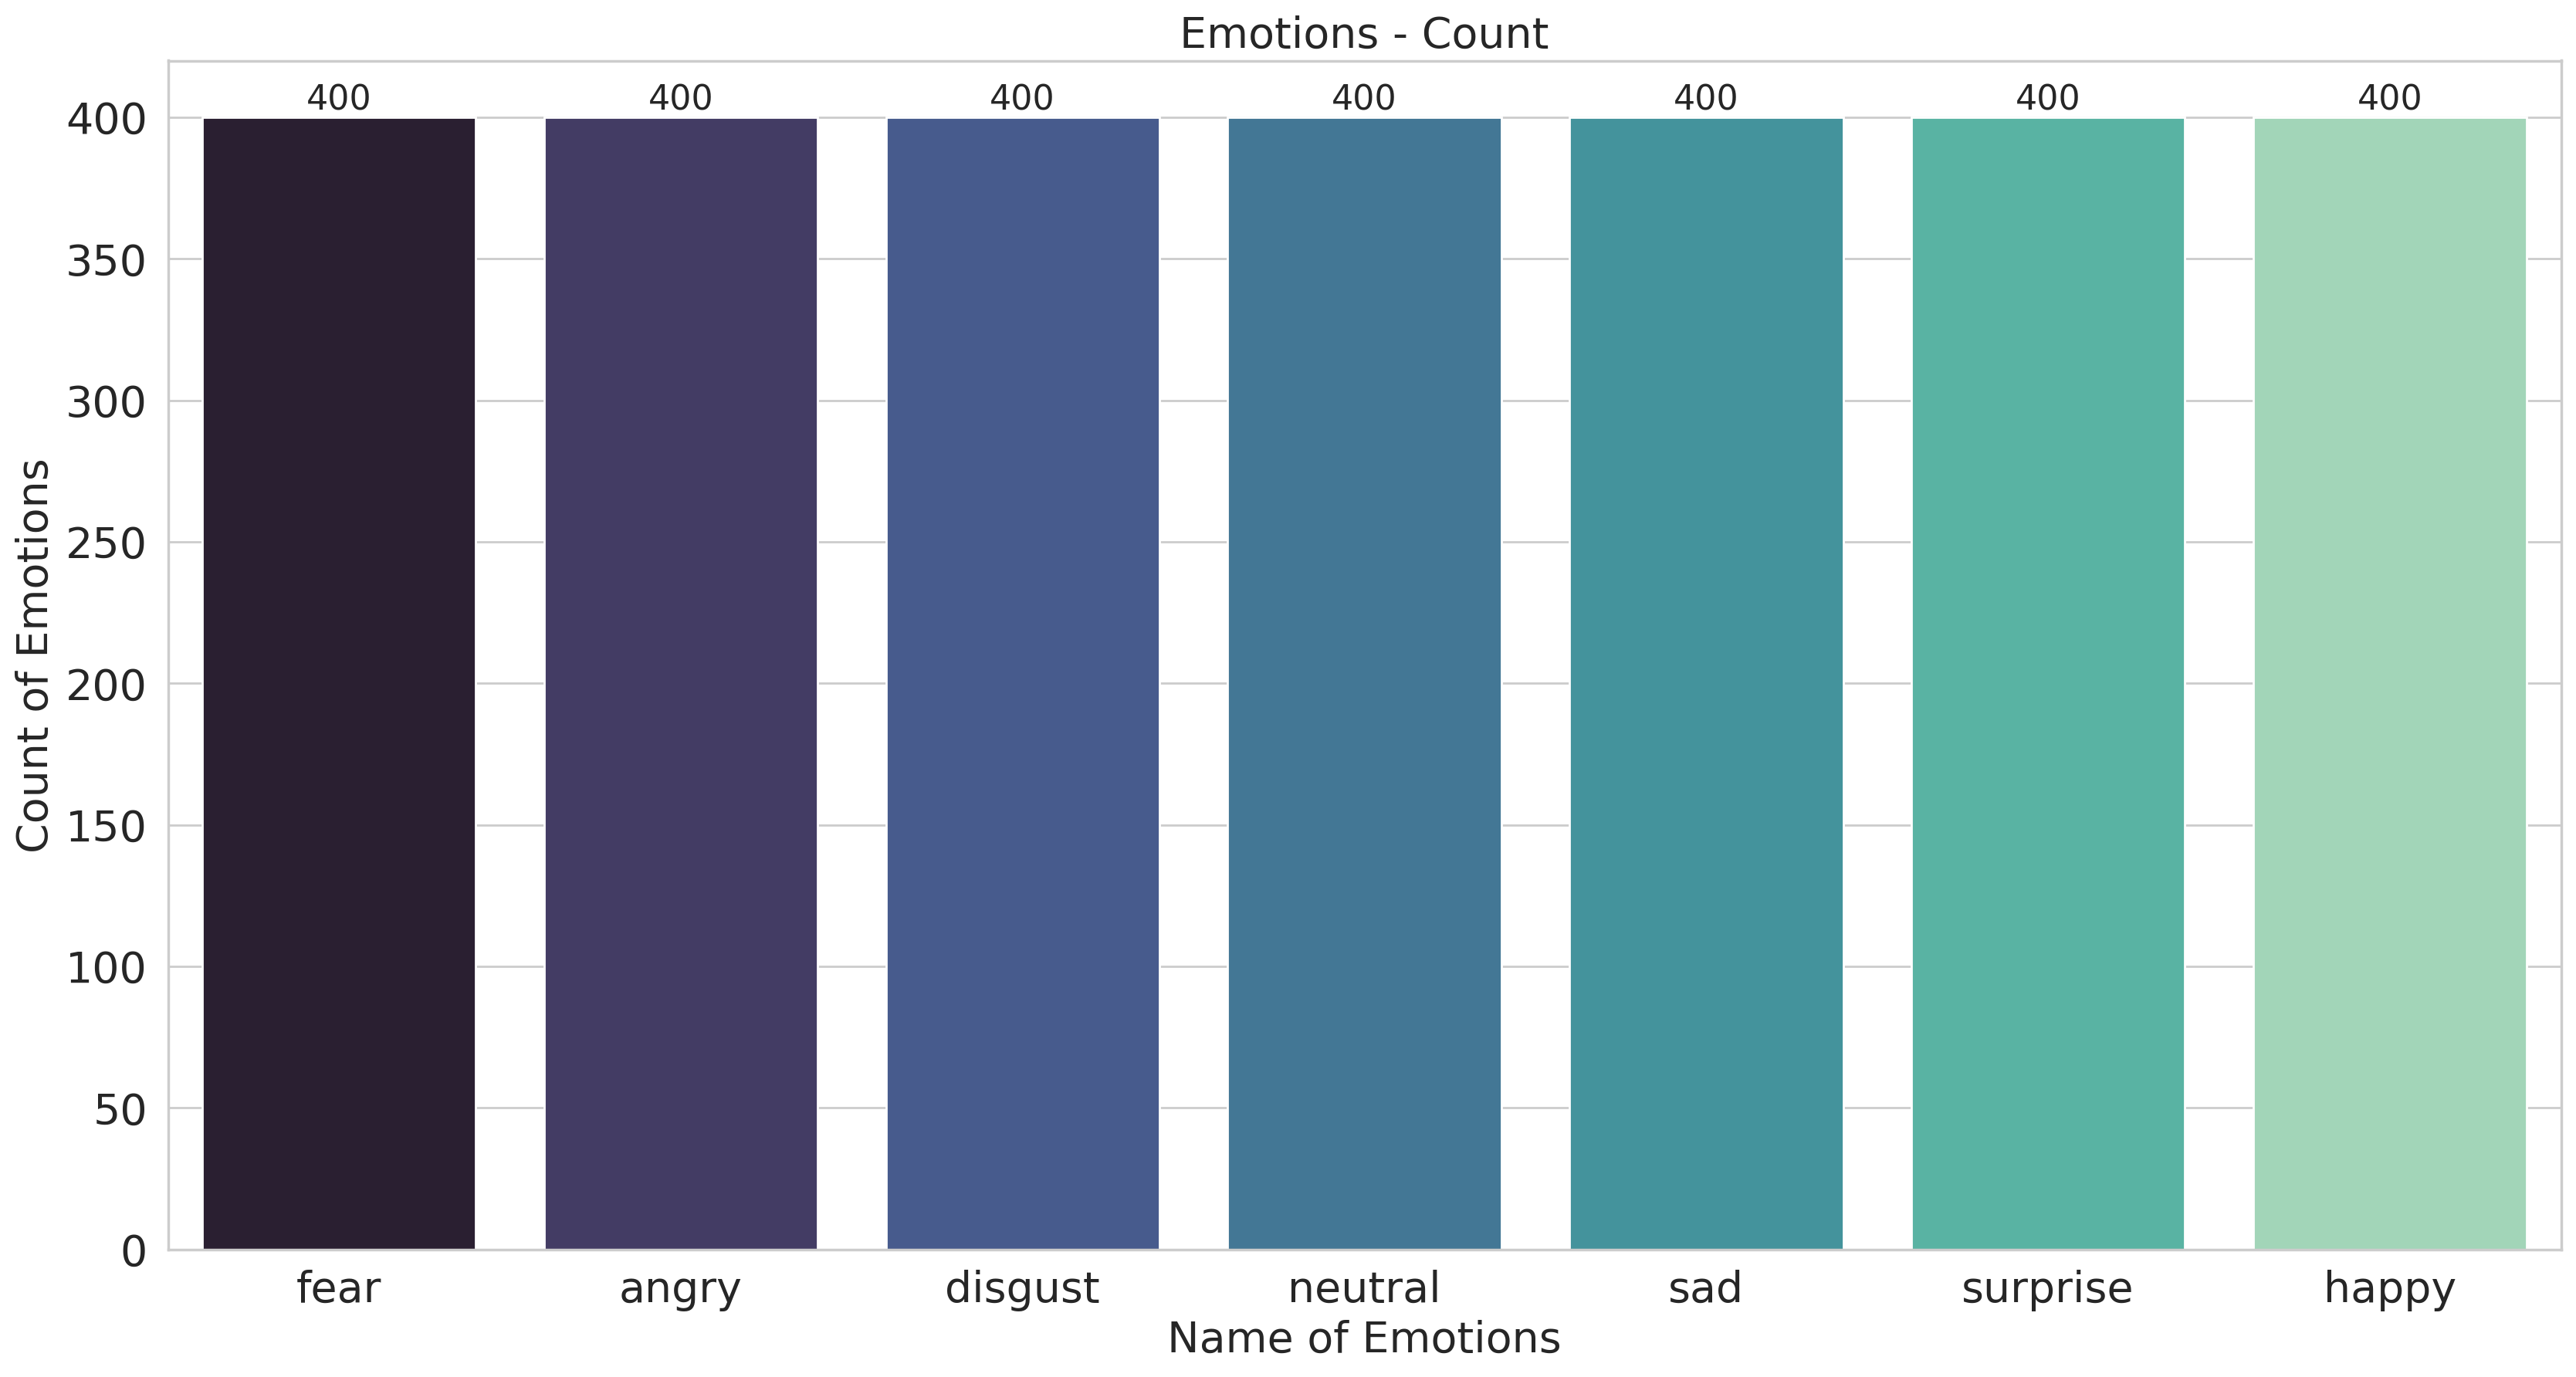

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", color_codes=True)
plt.figure(figsize=(20, 10), dpi=200)

# Calculate emotion counts
Count_emotion = Tess_df['Emotions'].value_counts()[:]

# Plot vertical bar plot
ax = sns.barplot(x=Count_emotion.index, y=Count_emotion, palette="mako")
ax.bar_label(ax.containers[0], fontsize=16)

# Update tick font sizes and labels
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Name of Emotions", fontsize=20)
plt.ylabel("Count of Emotions", fontsize=20)
plt.title("Emotions - Count", fontsize=20)

# Display the plot
plt.show()


## Data Augmentation

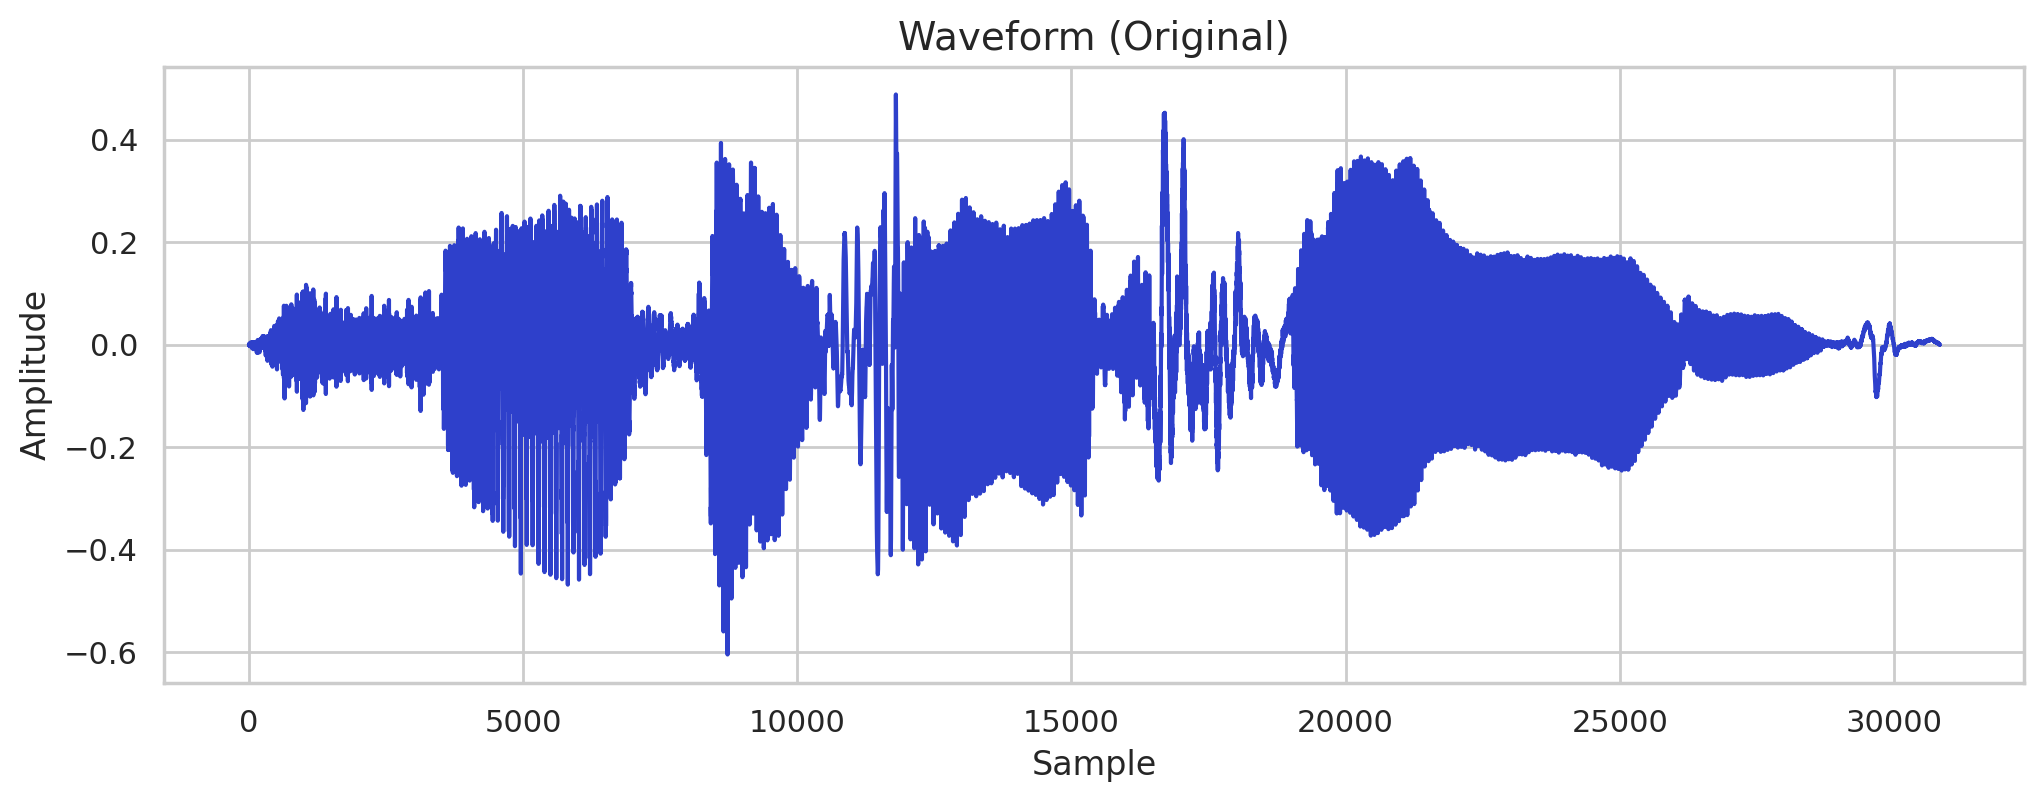

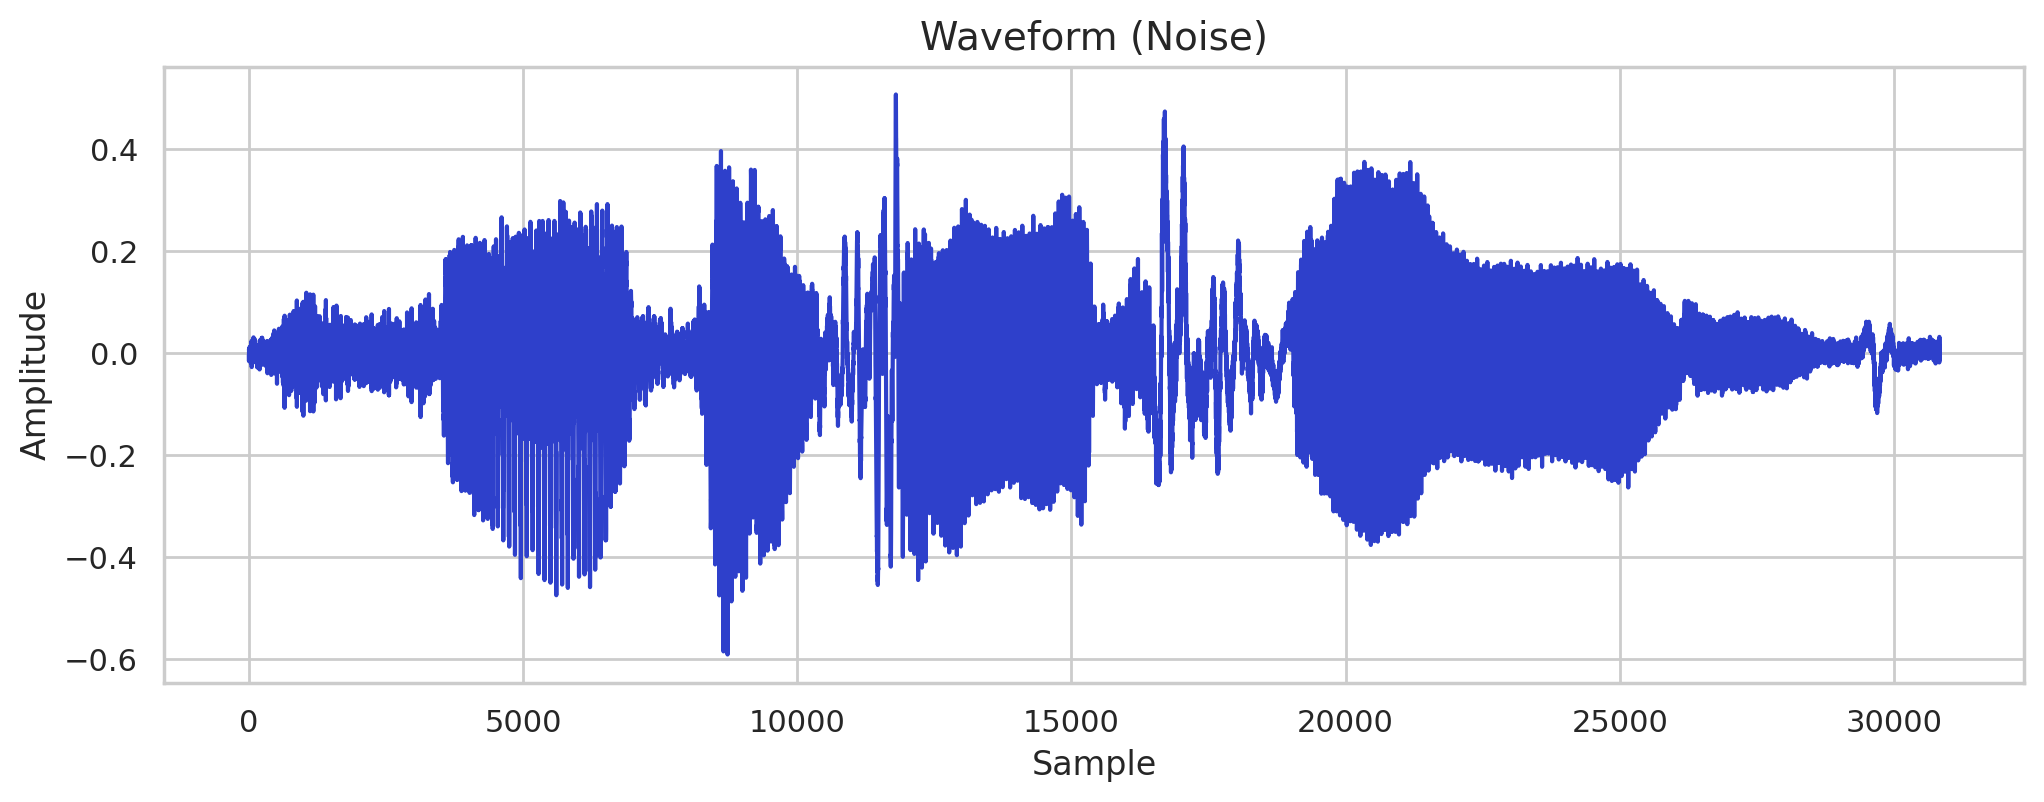

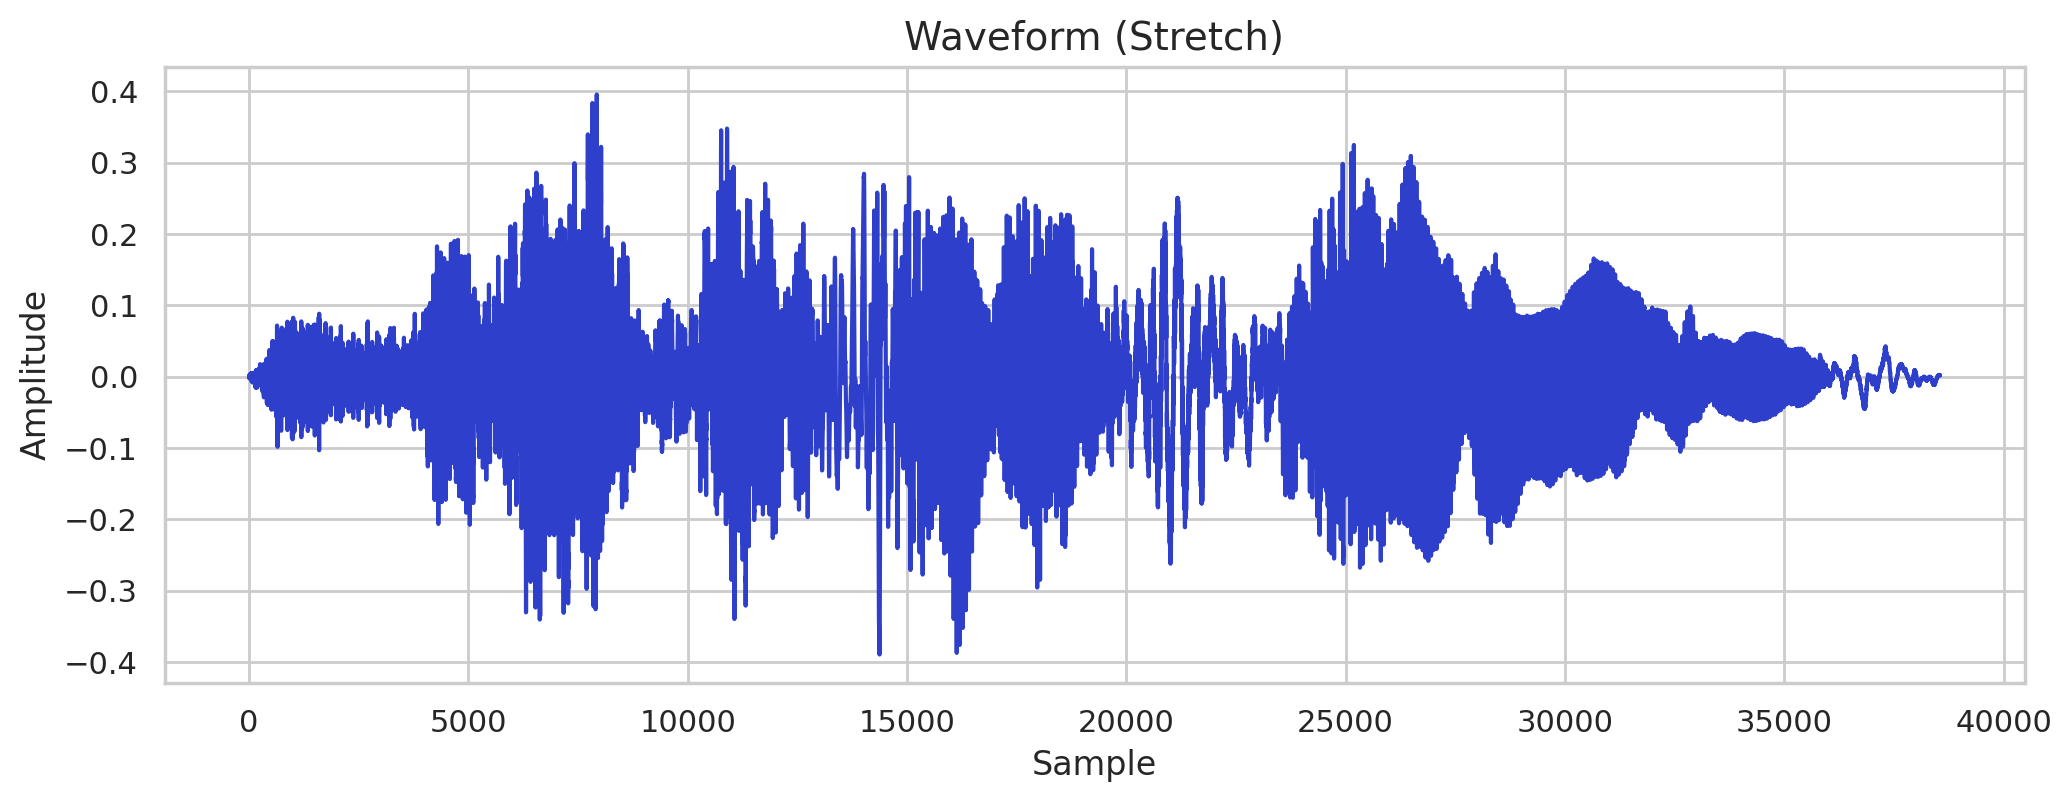

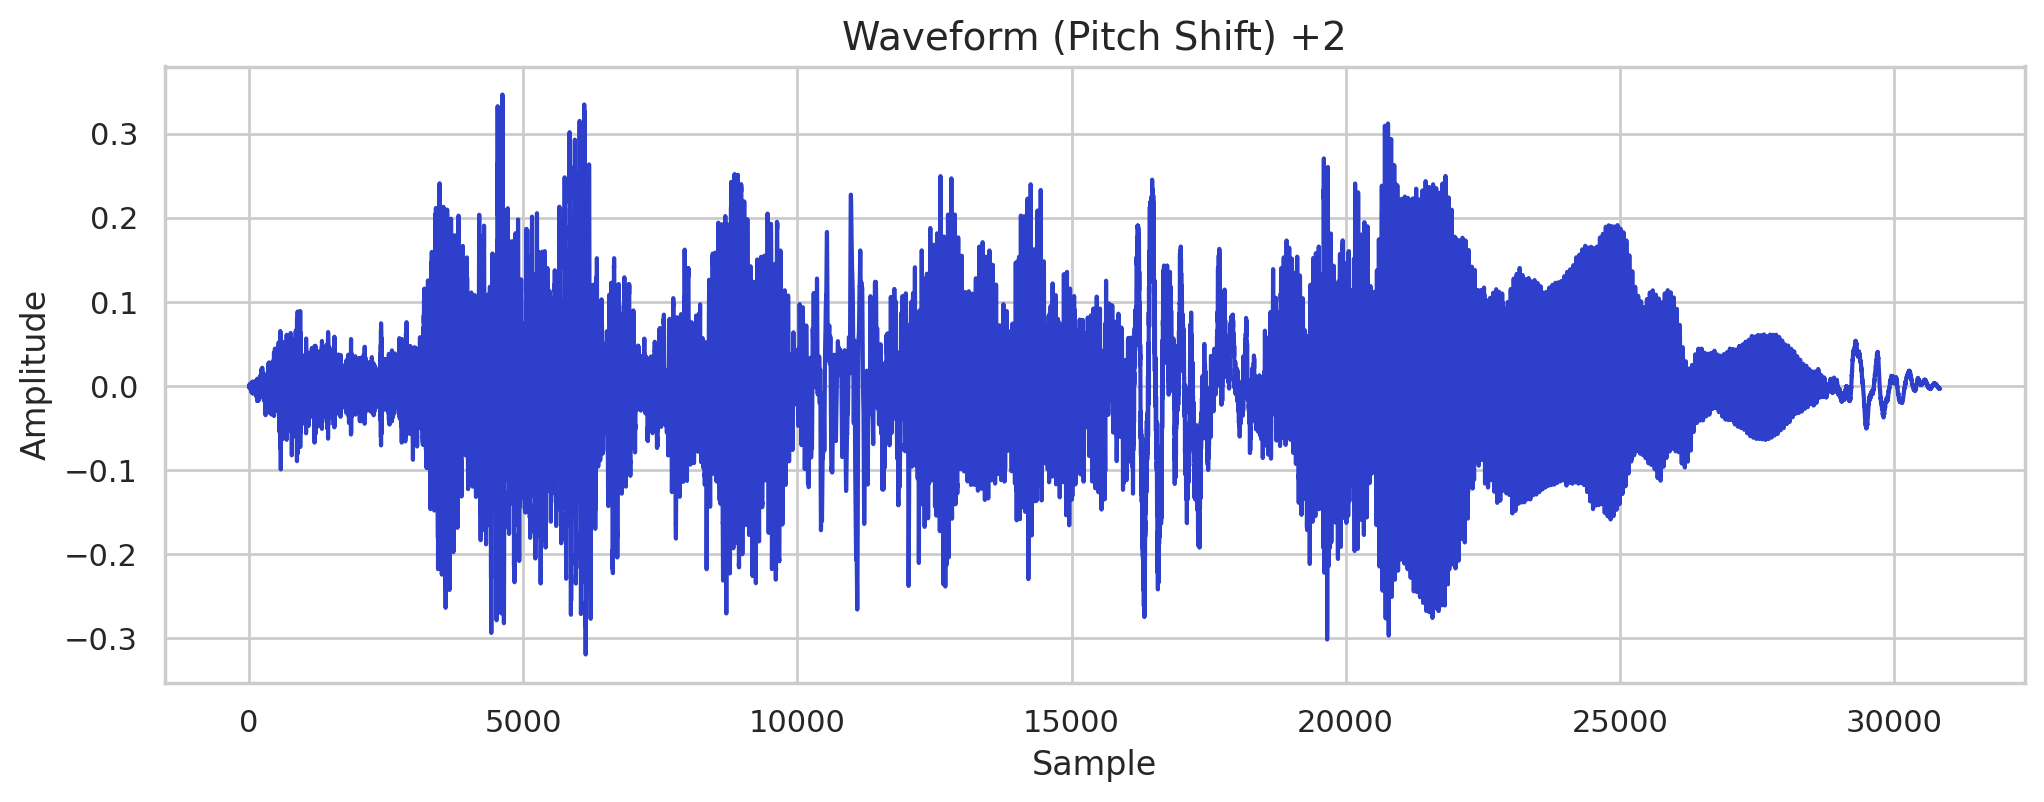

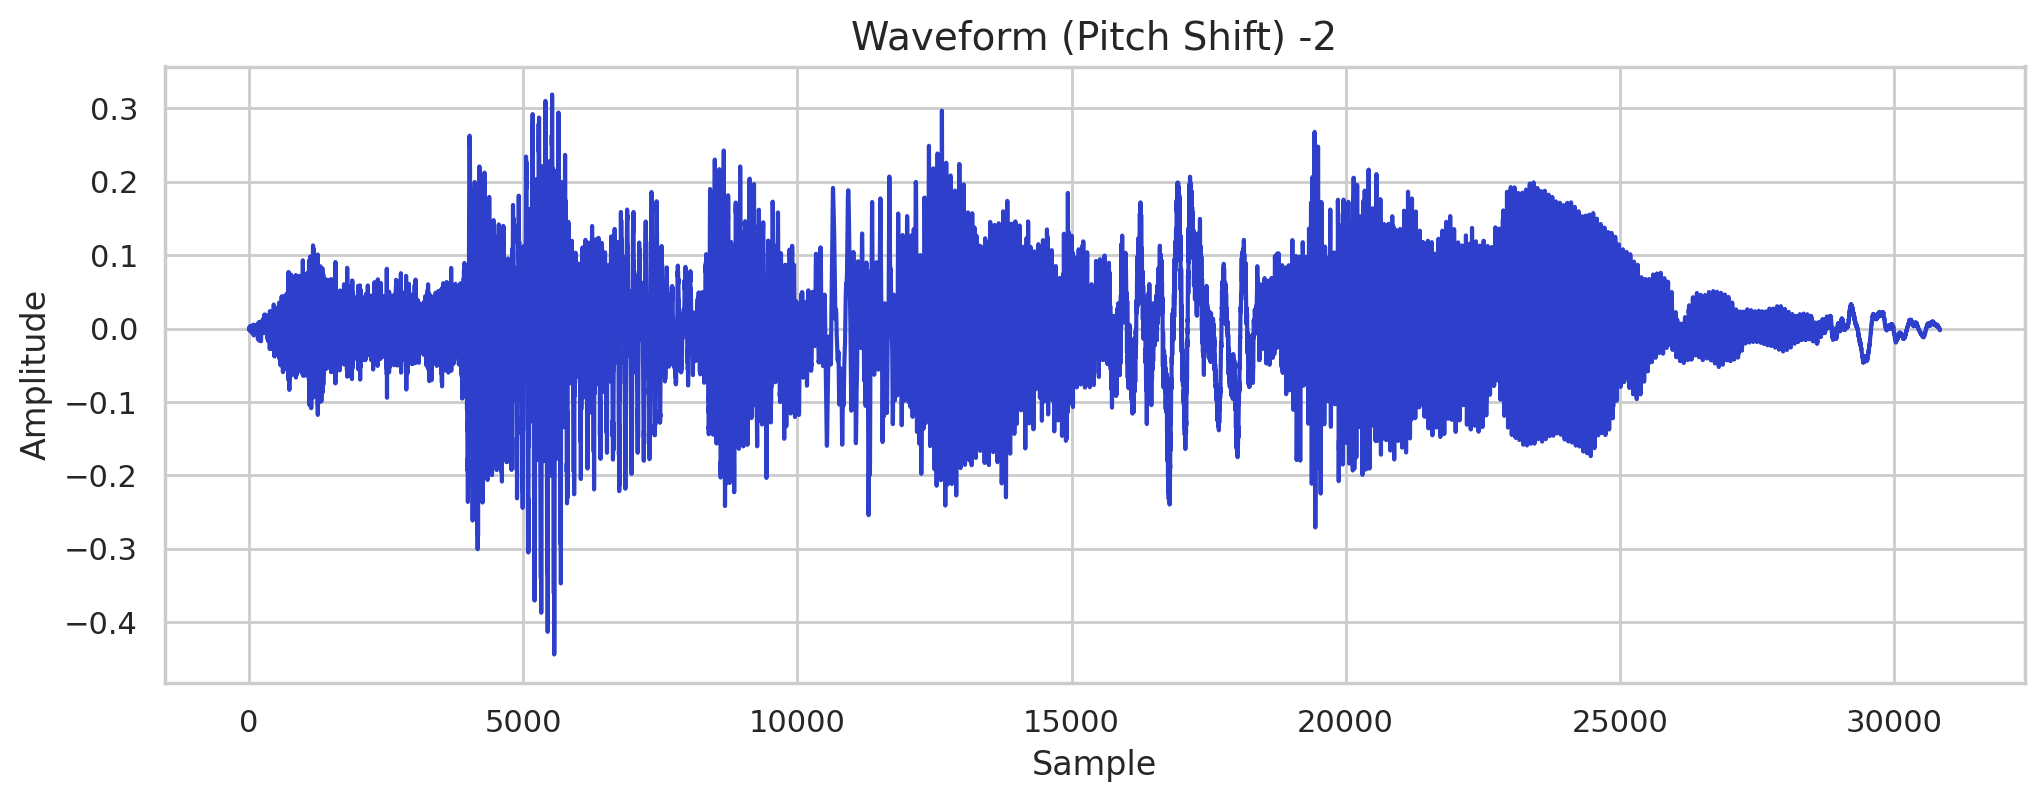

In [13]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

def noise(data):
    """Add random noise to the audio signal."""
    noise_amp = 0.035 * np.random.uniform() * np.amax(data)
    data = data + noise_amp * np.random.normal(size=data.shape[0])
    return data

# Function for time stretching
def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(data, rate=rate)

def apply_pitch_shift(data, sr, n_steps=2):
    """Apply pitch shift to the audio signal."""
    return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=n_steps)


# Example usage
data, sample_rate = librosa.load(file_path[0])

# Visualizing and listening to the original audio signal
plt.figure(figsize=(12, 4), dpi=200)
plt.plot(data, color='#2E40CB')
plt.xlabel('Sample', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title('Waveform (Original)', fontsize=14)
plt.show()

# Listen to the original audio
display(Audio(data, rate=sample_rate))

# Apply Noise augmentation
Noise_data = noise(data)
plt.figure(figsize=(12, 4), dpi=200)
plt.plot(Noise_data, color='#2E40CB')
plt.xlabel('Sample', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title('Waveform (Noise)', fontsize=14)
plt.show()

# Listen to the audio with noise
display(Audio(Noise_data, rate=sample_rate))

# Apply Time Stretching
Stretch_data = stretch(data, rate=0.8)  # You can change the rate as needed
plt.figure(figsize=(12, 4), dpi=200)
plt.plot(Stretch_data, color='#2E40CB')
plt.xlabel('Sample', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title('Waveform (Stretch)', fontsize=14)
plt.show()

# Listen to the stretched audio
display(Audio(Stretch_data, rate=sample_rate))

# Apply Pitch Shifting +2
Pitch_shifted_data = apply_pitch_shift(data, sample_rate, n_steps=2)
plt.figure(figsize=(12, 4), dpi=200)
plt.plot(Pitch_shifted_data, color='#2E40CB')
plt.xlabel('Sample', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title('Waveform (Pitch Shift) +2', fontsize=14)
plt.show()

# Listen to the pitch-shifted audio
display(Audio(Pitch_shifted_data, rate=sample_rate))

# Apply Pitch Shifting -2
Pitch_shifted_data_2 = apply_pitch_shift(data, sample_rate, n_steps=-2)
plt.figure(figsize=(12, 4), dpi=200)
plt.plot(Pitch_shifted_data_2, color='#2E40CB')
plt.xlabel('Sample', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title('Waveform (Pitch Shift) -2', fontsize=14)
plt.show()

# Listen to the pitch-shifted audio
display(Audio(Pitch_shifted_data_2, rate=sample_rate))

# MEL SPECTROGRAM

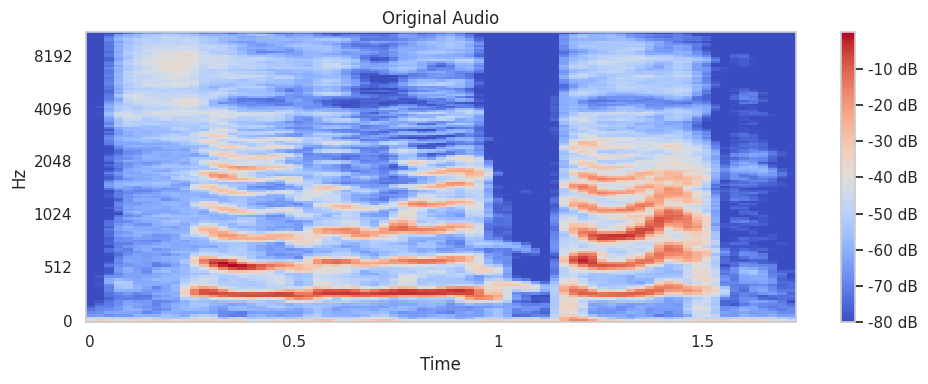

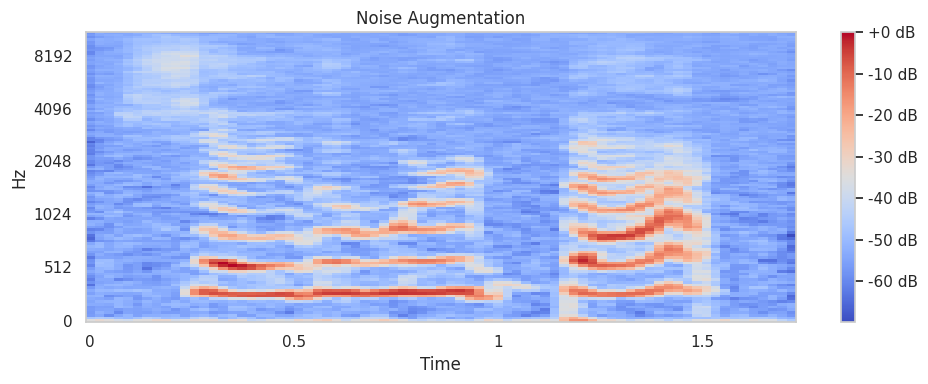

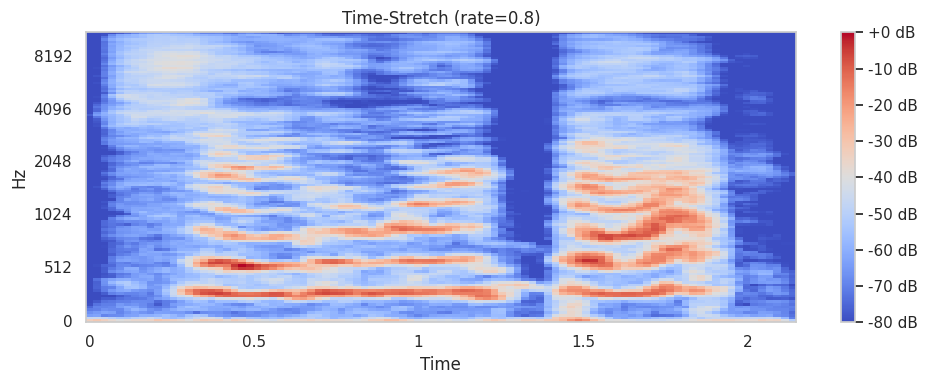

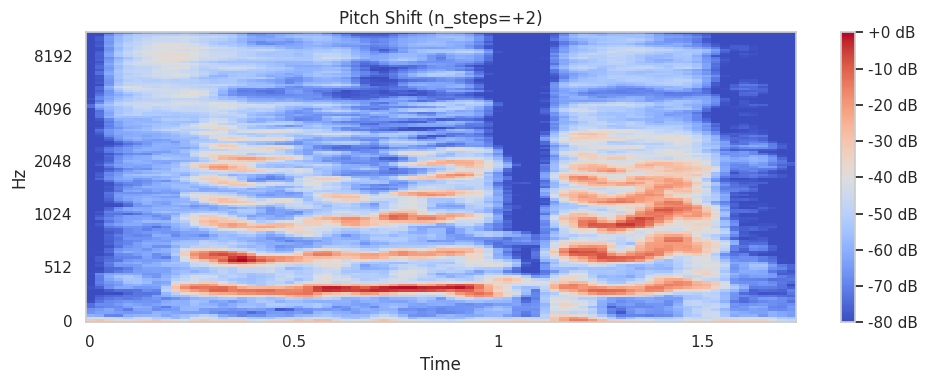

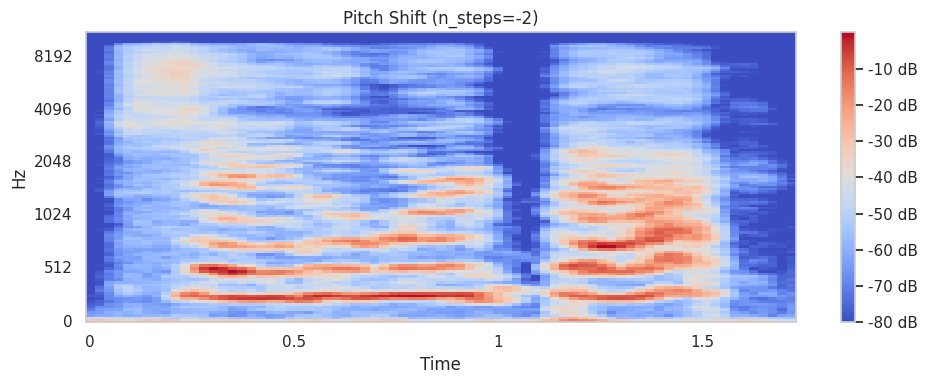

In [14]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

def plot_spectrogram(data, sr, title="Spectrogram"):
    """
    Plot the spectrogram for the given audio data.
    Args:
    - data: Audio signal
    - sr: Sampling rate
    - title: Title for the plot
    """
    spectrogram = librosa.feature.melspectrogram(y=data, sr=sr)
    log_spectrogram = librosa.power_to_db(spectrogram, ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(log_spectrogram, x_axis="time", y_axis="mel", sr=sr, cmap="coolwarm")
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def visualize_augmentations(data, sr):
    """
    Visualize the spectrograms for original and augmented audio data.
    Args:
    - data: Original audio signal
    - sr: Sampling rate
    """
    # Dictionary to hold augmented data with titles
    augmentations = {
        "Original Audio": data,
        "Noise Augmentation": noise(data),
        "Time-Stretch (rate=0.8)": stretch(data, rate=0.8),
        "Pitch Shift (n_steps=+2)": apply_pitch_shift(data, sr, n_steps=2),
        "Pitch Shift (n_steps=-2)": apply_pitch_shift(data, sr, n_steps=-2),
    }

    # Plot each augmentation's spectrogram
    for title, augmented_data in augmentations.items():
        plot_spectrogram(augmented_data, sr, title=title)

# Example: Load an audio file
path = '/kaggle/input/speech-emotion-recognition-en/Tess/OAF_Fear/OAF_back_fear.wav'  # Replace with your actual file path
data, sample_rate = librosa.load(path)

# Call the function to visualize augmentations
visualize_augmentations(data, sample_rate)

## Feature Extraction

In [15]:
Tess_df

,Emotions,Path
0,fear,/kaggle/input/speech-emotion-recognition-en/Te...
1,fear,/kaggle/input/speech-emotion-recognition-en/Te...
2,fear,/kaggle/input/speech-emotion-recognition-en/Te...
3,fear,/kaggle/input/speech-emotion-recognition-en/Te...
4,fear,/kaggle/input/speech-emotion-recognition-en/Te...
...,...,...
2795,surprise,/kaggle/input/speech-emotion-recognition-en/Te...
2796,surprise,/kaggle/input/speech-emotion-recognition-en/Te...
2797,surprise,/kaggle/input/speech-emotion-recognition-en/Te...
2798,surprise,/kaggle/input/speech-emotion-recognition-en/Te...


In [16]:
#Mel-frequency cepstral coefficients
def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration = 3, offset = 0.5)
    mfcc = np.mean(librosa.feature.mfcc(y = y, sr = sr, n_mfcc = 40).T, axis = 0)
    return mfcc

extract_mfcc(Tess_df['Path'][0])

array([-285.73727  ,   85.78295  ,   -2.1689117,   22.125532 ,
        -14.757396 ,   11.051347 ,   12.412449 ,   -3.000262 ,
          1.0844985,   11.078271 ,  -17.41966  ,   -8.093213 ,
          6.5879736,   -4.2209525,   -9.15508  ,    3.5214796,
        -13.186381 ,   14.078853 ,   19.66973  ,   22.725618 ,
         32.57464  ,   16.325033 ,   -3.8427284,    0.8962967,
        -11.239264 ,    6.653461 ,   -2.5883694,   -7.7140164,
        -10.941657 ,   -2.4007552,   -5.2812862,    4.271157 ,
        -11.202216 ,   -9.024621 ,   -3.666985 ,    4.8697433,
         -1.6027987,    2.5600514,   11.454374 ,   11.233449 ],
      dtype=float32)

In [ ]:
# Assume `Tess_df` is your DataFrame containing audio file paths and emotions
emotion_groups = Tess_df.groupby("Emotions")["Path"].apply(list)  # Group by emotion

mfcc_means = {}

for emotion, file_paths in emotion_groups.items():
    all_mfccs = [extract_mfcc(file) for file in file_paths]  # Extract MFCCs for all files in an emotion
    mfcc_means[emotion] = np.mean(all_mfccs, axis=0)  # Compute the average MFCC per emotion

# Convert to DataFrame for visualization
df_mfcc_means = pd.DataFrame(mfcc_means)

# Plot Mean MFCC Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_mfcc_means, cmap="coolwarm", annot=False)
plt.xlabel("Emotions")
plt.ylabel("MFCC Coefficients")
plt.title("Mean MFCC Comparison Across Emotions")
plt.show()


In [ ]:
df_mfcc_means

In [17]:
%%time
X_mfcc = Tess_df['Path'].apply(lambda x: extract_mfcc(x))

CPU times: user 2min 39s, sys: 3min, total: 5min 39s
Wall time: 1min 39s


In [18]:
X_mfcc

0       [-285.73727, 85.78295, -2.1689117, 22.125532, ...
1       [-348.34332, 35.193233, -3.8413284, 14.658875,...
2       [-340.11435, 53.796444, -14.267782, 20.884031,...
3       [-306.63422, 21.259708, -4.4110823, 6.4871554,...
4       [-344.7548, 46.329193, -24.171413, 19.392921, ...
                              ...                        
2795    [-374.3952, 60.864998, 0.02505877, 8.431058, -...
2796    [-313.96478, 39.847843, -5.6493053, -3.8675754...
2797    [-357.54886, 77.88605, -15.224756, 2.194633, -...
2798    [-353.1474, 101.68391, -14.175897, -12.037376,...
2799    [-389.4595, 54.042767, 1.3469982, -1.4258989, ...
Name: Path, Length: 2800, dtype: object

## Array and Dimension

In [19]:
X = [x for x in X_mfcc]
X = np.array(X)
X.shape

(2800, 40)

In [20]:
## input split
X = np.expand_dims(X, -1)
X.shape

(2800, 40, 1)

In [21]:
enc = OneHotEncoder()
y = enc.fit_transform(Tess_df[['Emotions']])

In [22]:
y = y.toarray()

In [23]:
y

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

## LSTM Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Update target names based on the TESS dataset's emotion classes
target_names = ['Neutral', 'Happy', 'Sad', 'Angry', 'Fear', 'Disgust', 'Surprise']  # Adjust as per TESS dataset

# Initialize the LSTM model
model = Sequential([
    LSTM(256, return_sequences=False, input_shape=(40, 1)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(len(target_names), activation='softmax')  # Adjust output layer for TESS's number of emotions
])

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Display the model summary
model.summary()

# Train the model
history = model.fit(
    X, y,  # Ensure `X` and `y` are the processed TESS dataset
    validation_split=0.2,
    batch_size=64,
    epochs=300
)

# Function to plot history
def plot_history(history):
    plt.figure(figsize=(12, 4), dpi=200)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.figure(figsize=(12, 4), dpi=200)
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

# Plot training history
plot_history(history)

# Evaluate the model
evaluation = model.evaluate(X, y, verbose=0)
print(f"Loss: {evaluation[0]:.8f}, Accuracy: {evaluation[1]:.8f}")

# Confusion Matrix and Classification Report
y_pred = model.predict(X, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Classification report
report = classification_report(y_true, y_pred_classes, target_names=target_names, digits=8)
print(report)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 256)                 │         264,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │             455 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 305,799 (1.17 MB)

 Trainable params: 305,799 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.4905 - loss: 1.4353 - val_accuracy: 0.2196 - val_loss: 2.8521
Epoch 2/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.8138 - loss: 0.4979 - val_accuracy: 0.3643 - val_loss: 2.3320
Epoch 3/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.9328 - loss: 0.2499 - val_accuracy: 0.6554 - val_loss: 1.2945
Epoch 4/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.9381 - loss: 0.1917 - val_accuracy: 0.5286 - val_loss: 1.9803
Epoch 5/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.9694 - loss: 0.0928 - val_accuracy: 0.5107 - val_loss: 2.1071
Epoch 6/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.9650 - loss: 0.1095 - val_accuracy: 0.4036 - val_loss: 2.0973
Epoch 7/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.9729 - loss: 0.0909 - val_accuracy: 0.3554 - val_loss: 2.8886
Epoch 8/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.9752 - loss: 0.0848 - val_accu

## BiLSTM Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Update target names based on the TESS dataset's emotion classes
target_names = ['Neutral', 'Happy', 'Sad', 'Angry', 'Fear', 'Disgust', 'Surprise']

# Initialize the BiLSTM model
model = Sequential([
    Bidirectional(LSTM(256, return_sequences=False), input_shape=(40, 1)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(len(target_names), activation='softmax')  # Adjust output layer for TESS's number of emotions
])

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Display the model summary
model.summary()

# Train the model
history = model.fit(
    X, y,
    validation_split=0.2,
    batch_size=64,
    epochs=300
)

# Plot training history
plot_history(history)

# Evaluate the model
evaluation = model.evaluate(X, y, verbose=0)
print(f"Loss: {evaluation[0]:.8f}, Accuracy: {evaluation[1]:.8f}")

# Confusion Matrix and Classification Report
y_pred = model.predict(X, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

report = classification_report(y_true, y_pred_classes, target_names=target_names, digits=8)
print(report)

35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.9811 - loss: 0.0597 - val_accuracy: 0.4161 - val_loss: 3.1997
Epoch 8/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.9779 - loss: 0.0687 - val_accuracy: 0.2839 - val_loss: 4.7415
Epoch 9/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.9725 - loss: 0.0822 - val_accuracy: 0.3036 - val_loss: 3.5104
Epoch 10/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.9836 - loss: 0.0471 - val_accuracy: 0.2482 - val_loss: 4.5711
Epoch 11/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.9793 - loss: 0.0652 - val_accuracy: 0.3250 - val_loss: 3.2634
Epoch 12/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.9879 - loss: 0.0399 - val_accuracy: 0.3482 - val_loss: 4.0086
Epoch 13/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step - accuracy: 0.9874 - loss: 0.0376 - val_accuracy: 0.3089 - val_loss: 4.2943
Epoch 14/300
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.9945 - loss: 0.0212 - val_accura

## GRU Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Update target names based on the TESS dataset's emotion classes
target_names = ['Neutral', 'Happy', 'Sad', 'Angry', 'Fear', 'Disgust', 'Surprise']

# Initialize the GRU model
model = Sequential([
    GRU(256, return_sequences=False, input_shape=(40, 1)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(len(target_names), activation='softmax')  # Adjust output layer for TESS's number of emotions
])

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Display the model summary
model.summary()

# Train the model
history = model.fit(
    X, y,
    validation_split=0.2,
    batch_size=64,
    epochs=300
)

# Plot training history
plot_history(history)

# Evaluate the model
evaluation = model.evaluate(X, y, verbose=0)
print(f"Loss: {evaluation[0]:.8f}, Accuracy: {evaluation[1]:.8f}")

# Confusion Matrix and Classification Report
y_pred = model.predict(X, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

report = classification_report(y_true, y_pred_classes, target_names=target_names, digits=8)
print(report)

## BiGRU Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, GRU, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Update target names based on the TESS dataset's emotion classes
target_names = ['Neutral', 'Happy', 'Sad', 'Angry', 'Fear', 'Disgust', 'Surprise']

# Initialize the BiGRU model
model = Sequential([
    Bidirectional(GRU(256, return_sequences=False), input_shape=(40, 1)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(len(target_names), activation='softmax')  # Adjust output layer for TESS's number of emotions
])

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Display the model summary
model.summary()

# Train the model
history = model.fit(
    X, y,
    validation_split=0.2,
    batch_size=64,
    epochs=300
)

# Plot training history
plot_history(history)

# Evaluate the model
evaluation = model.evaluate(X, y, verbose=0)
print(f"Loss: {evaluation[0]:.8f}, Accuracy: {evaluation[1]:.8f}")

# Confusion Matrix and Classification Report
y_pred = model.predict(X, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

report = classification_report(y_true, y_pred_classes, target_names=target_names, digits=8)
print(report)